In [1]:
import warnings 
warnings.filterwarnings('ignore')


In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import KFold
from sklearn.ensemble import AdaBoostRegressor
%matplotlib inline 

In [2]:
import datetime

In [3]:
house_data=pd.read_csv('kc_house_data.csv')

In [4]:
house_data.shape

(21613, 21)

In [5]:
house_data.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [6]:
house_data.head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [7]:
#dropping ID column as this coulumn will not have any impact on price
house_data = house_data.drop('id',axis=1)

In [8]:
#House sale year may indicate current occupancy time. It may have impact on price. 
#But lets check how many unique years are there in the column. 

In [9]:
house_data['date'].astype(str).str.slice(0,4).unique()

array(['2014', '2015'], dtype=object)

In [10]:
#All houses are sold in 2014 and 2015. So 'date' column will not have any impact on price. So dropping this column too. 
house_data = house_data.drop('date',axis=1)

In [11]:
#Calucalting how old is the house. Once we get the age of the house then we can drop yr_built column
house_data['age_of_house'] = datetime.datetime.now().year - house_data['yr_built']

In [12]:
house_data[house_data['yr_renovated'] != 0]['yr_renovated'] = datetime.datetime.now().year - house_data['yr_renovated']

F:\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [13]:
house_data['reno_age'] = datetime.datetime.now().year - house_data['yr_renovated']

In [14]:
house_data['reno_age'].replace(2019,house_data['age_of_house'],inplace=True)

In [15]:
house_data.head(20)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,age_of_house,reno_age
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,64,64
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,68,28
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,86,86
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,54,54
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,32,32
5,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,...,1530,2001,0,98053,47.6561,-122.005,4760,101930,18,18
6,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,...,0,1995,0,98003,47.3097,-122.327,2238,6819,24,24
7,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,...,0,1963,0,98198,47.4095,-122.315,1650,9711,56,56
8,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,...,730,1960,0,98146,47.5123,-122.337,1780,8113,59,59
9,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,...,0,2003,0,98038,47.3684,-122.031,2390,7570,16,16


In [16]:
house_data = house_data.drop('yr_built',axis=1)

In [17]:
house_data = house_data.drop('yr_renovated',axis=1)


In [18]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
age_of_house     21613 non-null int64
reno_age         21613 non-null int64
dtypes: float64(5), int64(14)
memory usage: 3.1 MB


In [19]:
#I was expecting that bathroom and floors should be be integers, but it is float. So checking the unique values of 
#bathroom and floors
house_data['bathrooms'].unique()

array([1.  , 2.25, 3.  , 2.  , 4.5 , 1.5 , 2.5 , 1.75, 2.75, 3.25, 4.  ,
       3.5 , 0.75, 4.75, 5.  , 4.25, 3.75, 0.  , 1.25, 5.25, 6.  , 0.5 ,
       5.5 , 6.75, 5.75, 8.  , 7.5 , 7.75, 6.25, 6.5 ])

In [20]:
#Rounding off the float values
#house_data['bathrooms'] = round(house_data['bathrooms']).astype(int)
house_data['bathrooms'] = house_data['bathrooms'].apply(np.ceil).astype(int)

In [21]:
house_data['floors'].unique()

array([1. , 2. , 1.5, 3. , 2.5, 3.5])

In [22]:
#Rounding off the float values
#house_data['floors'] = round(house_data['floors']).astype(int)
house_data['floors'] = house_data['floors'].apply(np.ceil).astype(int)

In [23]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null int32
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null int32
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
age_of_house     21613 non-null int64
reno_age         21613 non-null int64
dtypes: float64(3), int32(2), int64(14)
memory usage: 3.0 MB


In [24]:
#since there are no object data type, it indicates that there are no null values. Lets reconfirm it. 
house_data.isnull().any()

price            False
bedrooms         False
bathrooms        False
sqft_living      False
sqft_lot         False
floors           False
waterfront       False
view             False
condition        False
grade            False
sqft_above       False
sqft_basement    False
zipcode          False
lat              False
long             False
sqft_living15    False
sqft_lot15       False
age_of_house     False
reno_age         False
dtype: bool

In [25]:
house_data.describe().T

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.141767,367127.196483,75000.0000,321950.000,450000.0000,645000.000,7.700000e+06
bedrooms,21613.0,3.370842,0.930062,0.0000,3.000,3.0000,4.000,3.300000e+01
bathrooms,21613.0,2.439273,0.923593,0.0000,2.000,3.0000,3.000,8.000000e+00
sqft_living,21613.0,2079.899736,918.440897,290.0000,1427.000,1910.0000,2550.000,1.354000e+04
sqft_lot,21613.0,15106.967566,41420.511515,520.0000,5040.000,7618.0000,10688.000,1.651359e+06
floors,21613.0,1.542405,0.567504,1.0000,1.000,2.0000,2.000,4.000000e+00
waterfront,21613.0,0.007542,0.086517,0.0000,0.000,0.0000,0.000,1.000000e+00
view,21613.0,0.234303,0.766318,0.0000,0.000,0.0000,0.000,4.000000e+00
condition,21613.0,3.409430,0.650743,1.0000,3.000,3.0000,4.000,5.000000e+00
grade,21613.0,7.656873,1.175459,1.0000,7.000,7.0000,8.000,1.300000e+01


In [18]:
temp_df = house_data[['age_of_house','price']]

In [19]:
temp_df.sort_values(['age_of_house'],inplace=True)

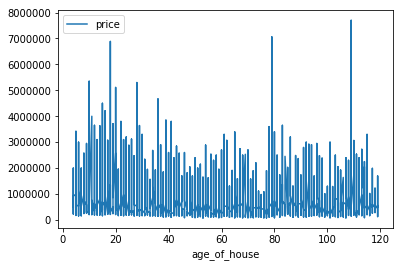

In [20]:
temp_df.plot.line(x='age_of_house',y='price')


In [26]:
house_data.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'age_of_house', 'reno_age'],
      dtype='object')

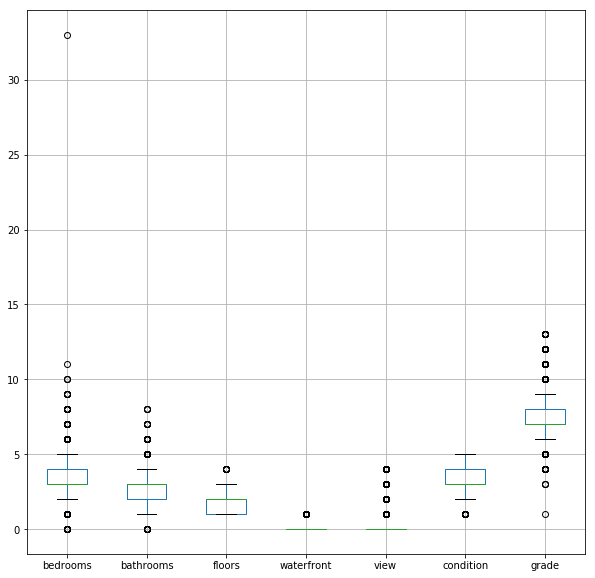

In [27]:
house_data.boxplot(column=['bedrooms', 'bathrooms','floors','waterfront', 'view','condition', 'grade'],figsize=(10,10))

In [28]:
#Lets check the houses which have more than 30 bedrooms
house_data[house_data['bedrooms']>30]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,age_of_house,reno_age
15870,640000.0,33,2,1620,6000,1,0,0,5,7,1040,580,98103,47.6878,-122.331,1330,4700,72,72


In [29]:
house_data = house_data[house_data['bedrooms']<30]

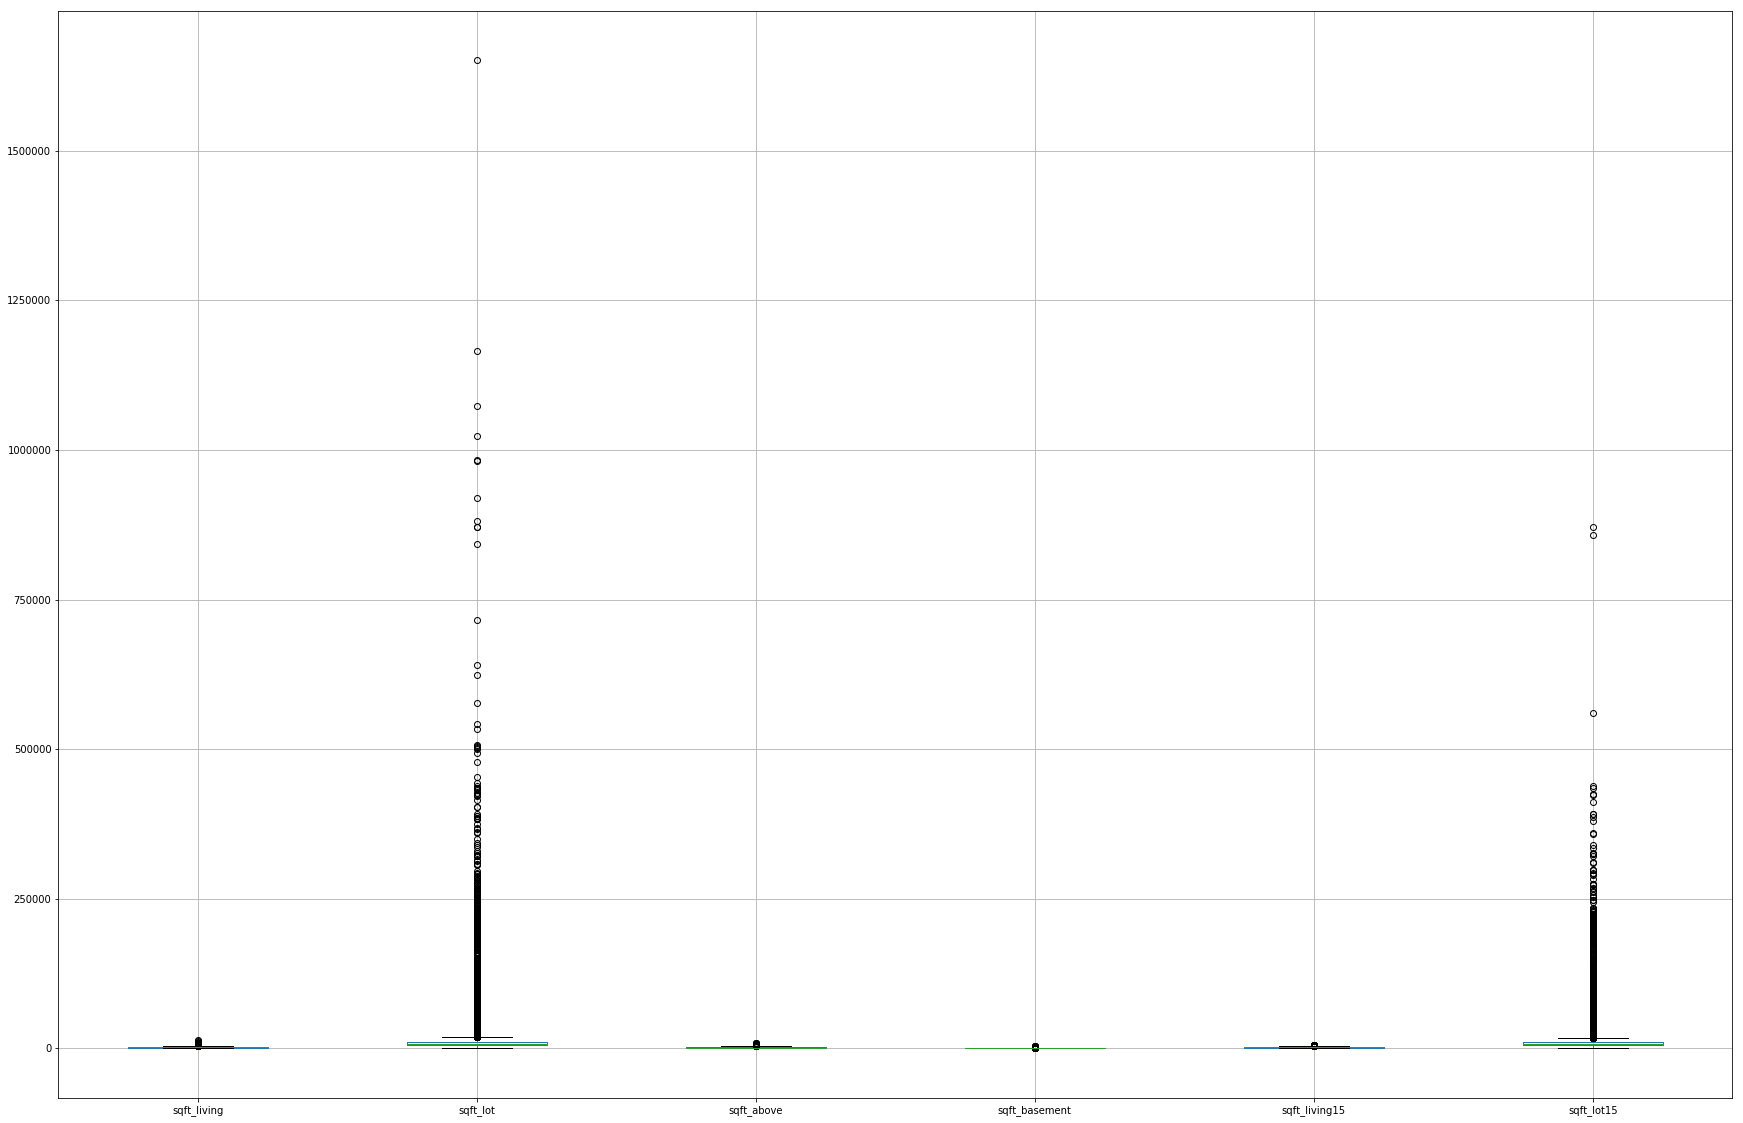

In [30]:
#plot Box Plots to check outlier
house_data.boxplot(column=['sqft_living', 'sqft_lot', 'sqft_above','sqft_basement','sqft_living15', 'sqft_lot15'],figsize=(30,20))

In [31]:
#sqft lot of few houses are too high, lets check them
house_data[house_data['sqft_lot']>1000000]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,age_of_house,reno_age
1719,700000.0,4,1,1300,1651359,1,0,3,4,6,1300,0,98022,47.2313,-122.023,2560,425581,99,99
7647,542500.0,5,4,3010,1074218,2,0,0,5,8,2010,1000,98027,47.4564,-122.004,2450,68825,88,88
7769,855000.0,4,4,4030,1024068,2,0,0,3,10,4030,0,98045,47.4619,-121.744,1830,11700,13,13
17319,190000.0,2,1,710,1164794,1,0,0,2,5,710,0,98014,47.6888,-121.909,1680,16730,104,104


In [32]:
#Removing the records which have sqft lot value more than 1000000. 
house_data = house_data[house_data['sqft_lot']<1000000]

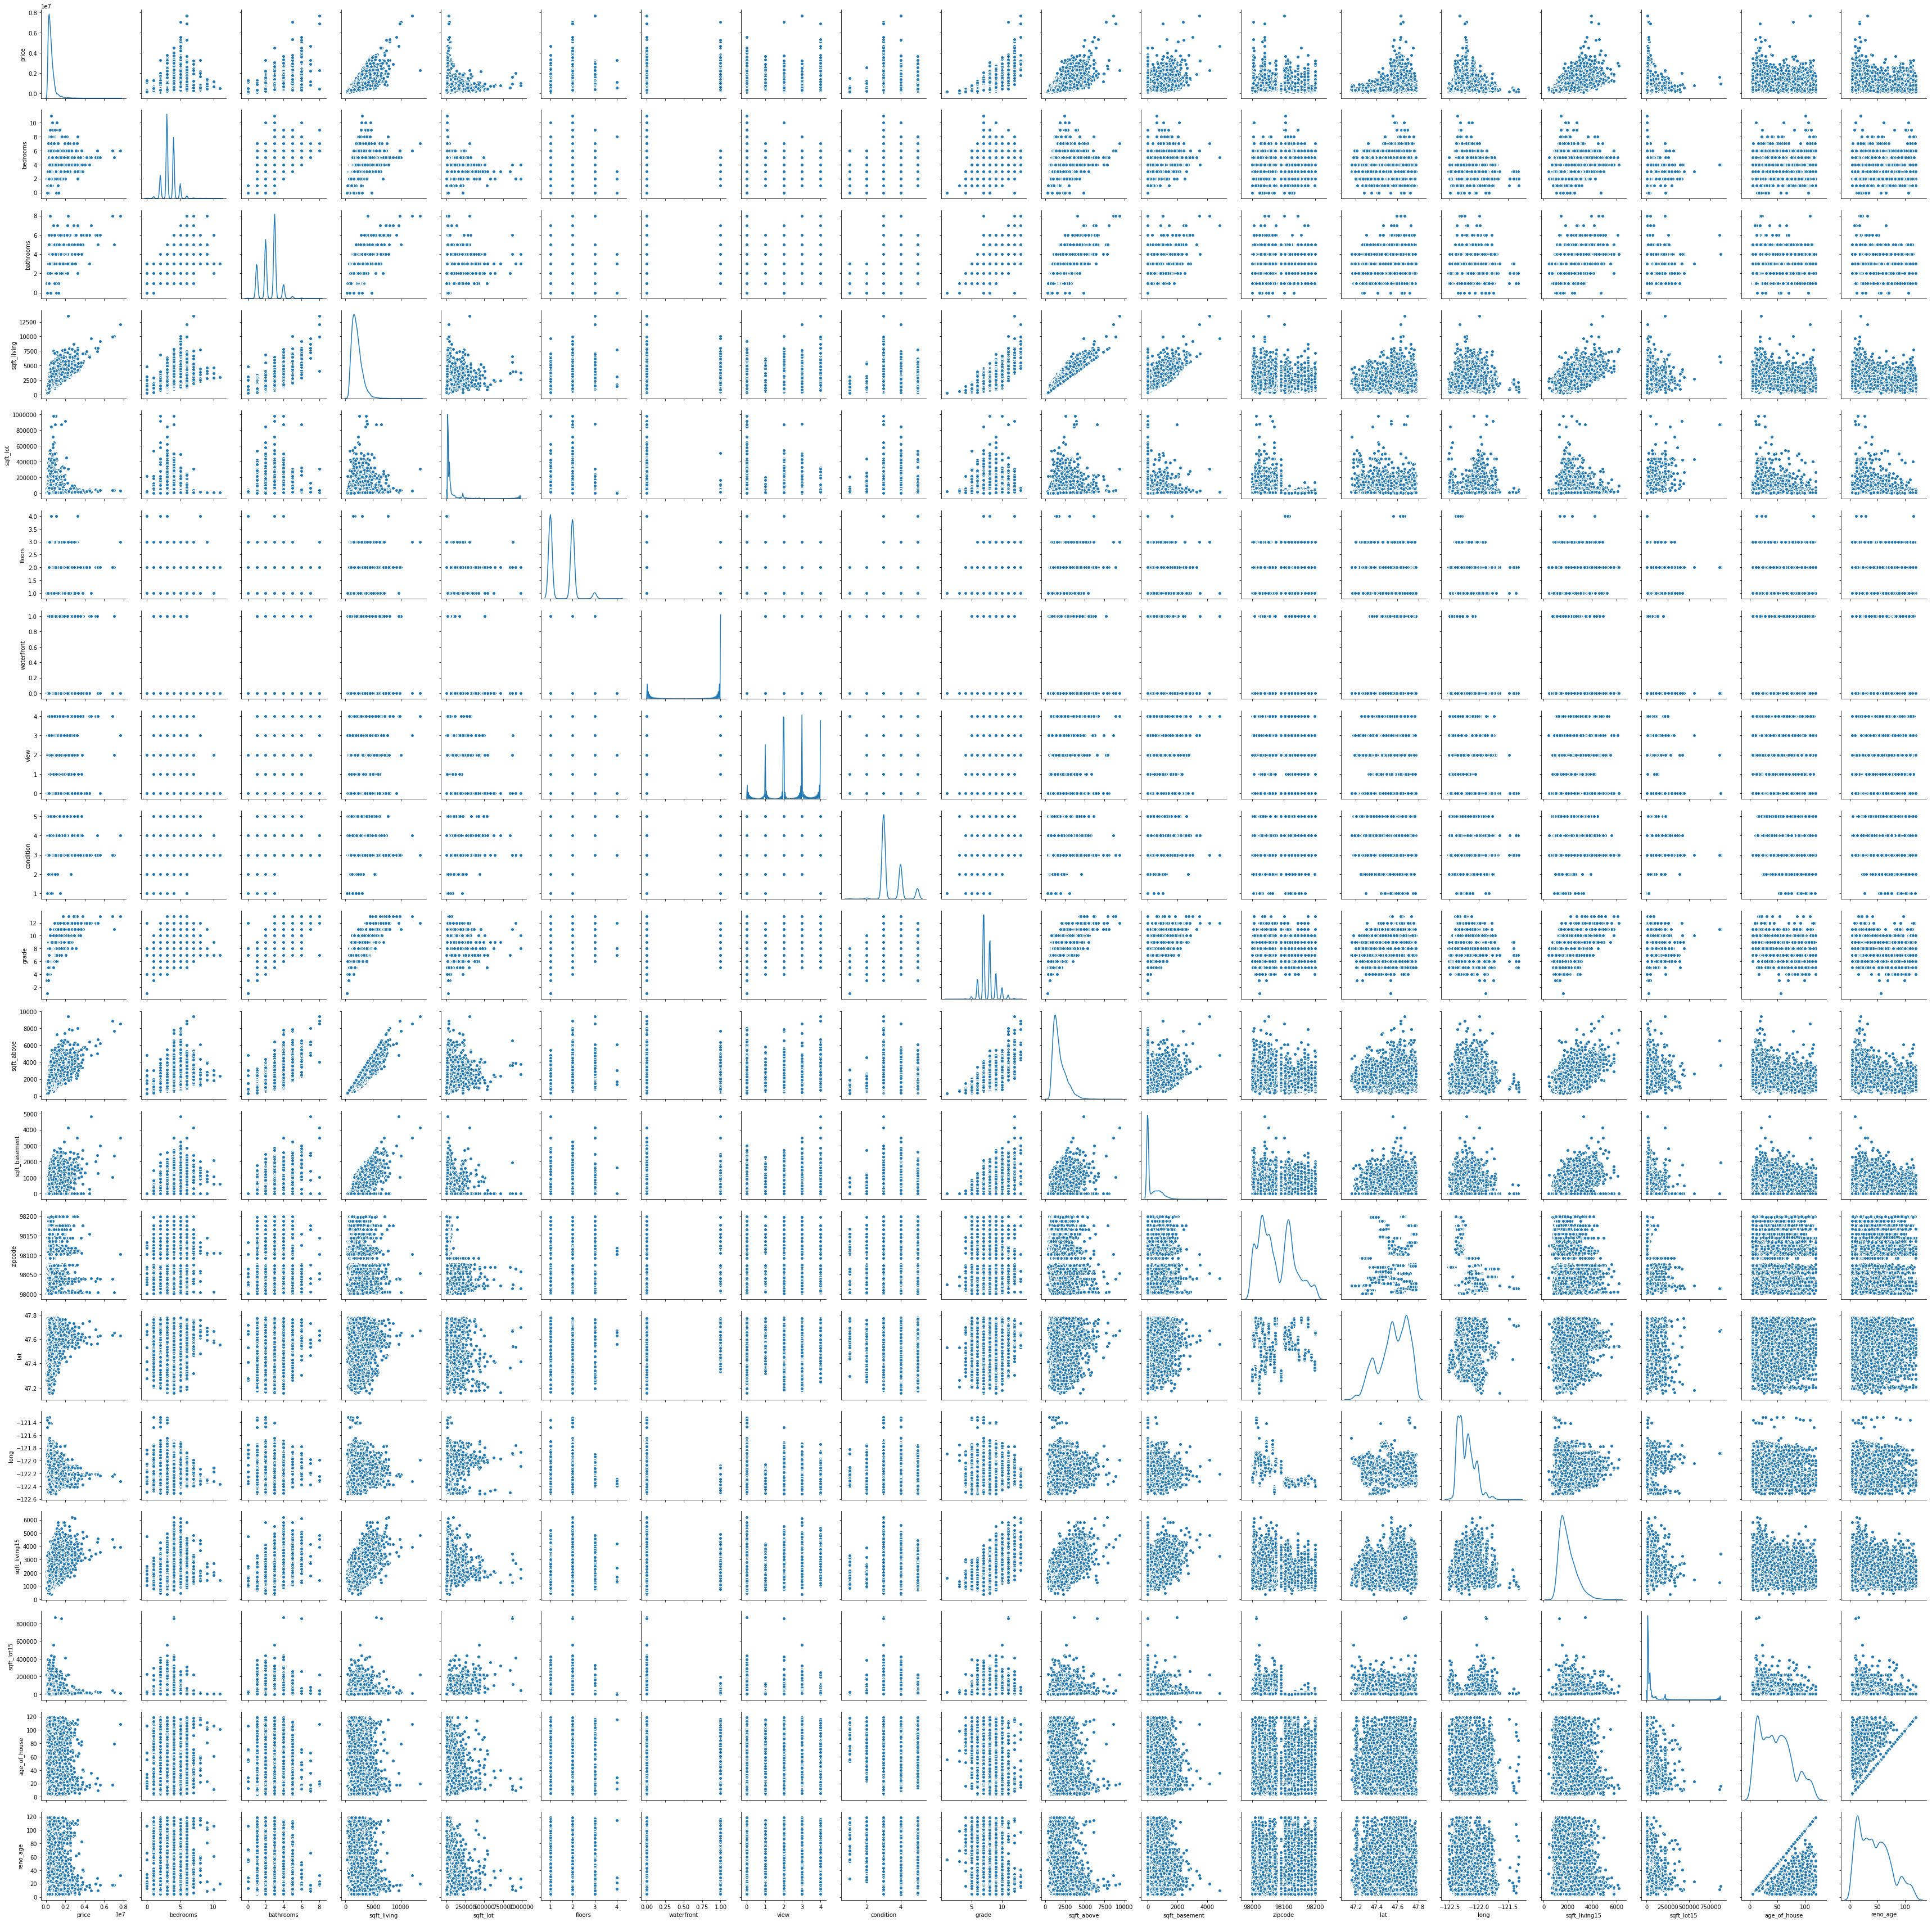

In [145]:
sns.pairplot(house_data,diag_kind='kde')

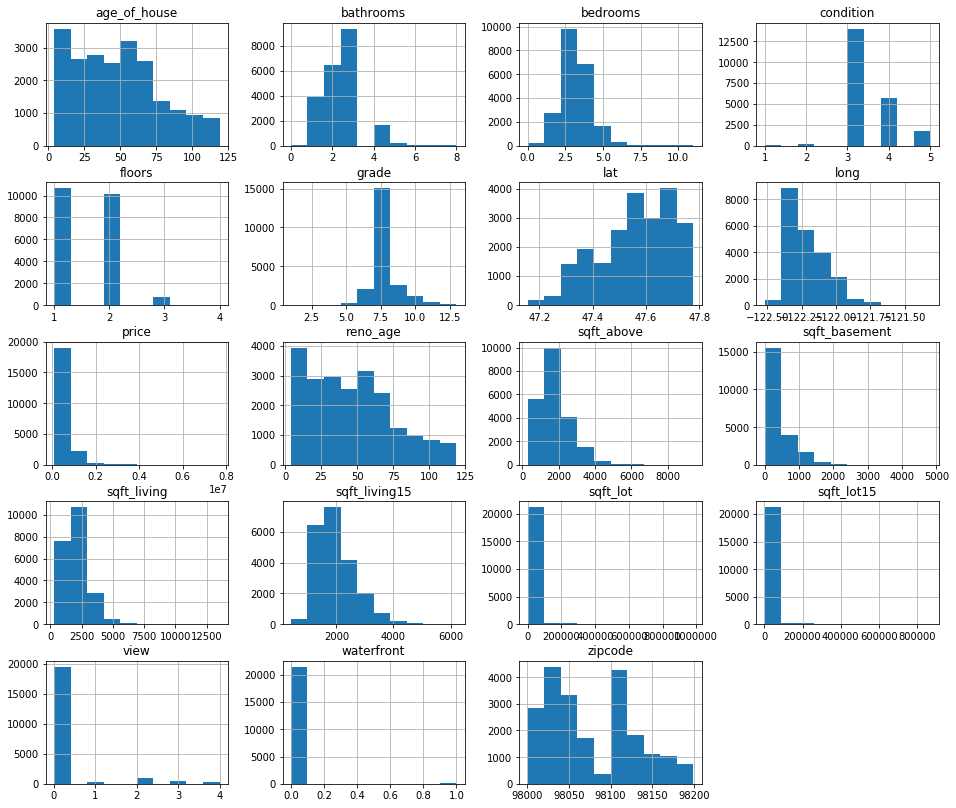

In [230]:
hist = house_data.hist(bins=10, figsize=(16, 14))

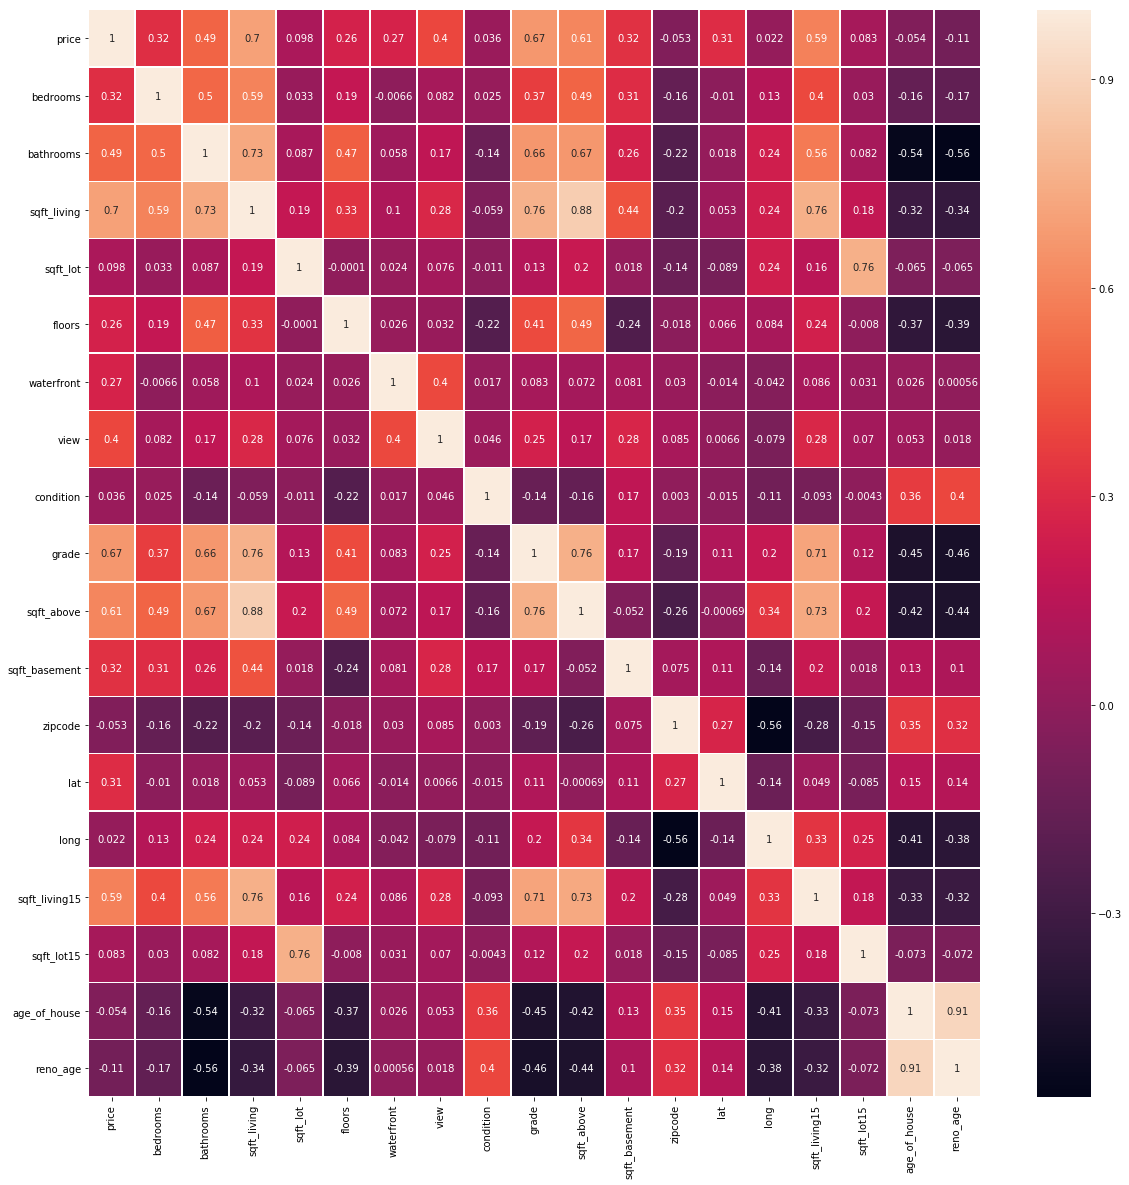

In [146]:
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(house_data.corr(),annot=True,linewidths=.5, ax=ax)

In [33]:
#Checking the correlation between price and other varriables. Variables with high correlation are mostly be used for prediction
cor = house_data.corr().iloc[0]
cor.sort_values(ascending = False)

price            1.000000
sqft_living      0.702081
grade            0.667497
sqft_above       0.605596
sqft_living15    0.585421
bathrooms        0.491909
view             0.397364
sqft_basement    0.323864
bedrooms         0.315397
lat              0.307182
waterfront       0.266384
floors           0.257993
sqft_lot         0.097565
sqft_lot15       0.082603
condition        0.036258
long             0.021583
zipcode         -0.053223
age_of_house    -0.053941
reno_age        -0.105703
Name: price, dtype: float64

In [34]:
#features with high correlation with target varriable will mostly be used in the model. So selecting 
#features which have abosolute value of correlation more than 0.3 - sqft_living, grade,sqft_above, 
#sqft_living15, bathrooms, view, sqft_basement , bedrooms, lat; storing these features in a list
#These features can be used, but lets check with other methods as well.
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors','waterfront', 'view', 
            'condition', 'grade', 'sqft_above','sqft_basement', 'zipcode', 'lat', 'long', 
            'sqft_living15','sqft_lot15', 'age_of_house', 'reno_age']
feature_corr = ['sqft_living', 'grade','sqft_above','sqft_living15','bathrooms','view','sqft_basement','bedrooms','lat']

In [35]:
X = house_data.drop('price', axis=1)
y = house_data['price']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [37]:
#Lets check the LinerRegression model with all parameters and check the coefficients.
lrmodel = LinearRegression()
lrmodel.fit(X_train, y_train)
y_predict = lrmodel.predict(X_test)
print(lrmodel.score(X_test, y_test))
print(metrics.mean_squared_error(y_predict, y_test))

0.6863668604740503
48637160115.984604


In [38]:
coef_list = lrmodel.coef_
abs_coef_list = map(abs, coef_list)
feature_dict = dict(zip(features, abs_coef_list))

In [39]:
import operator
sorted_feature_dict = sorted(feature_dict.items(), key=operator.itemgetter(1),reverse=True)
sorted_feature_dict

[('lat', 600378.6340794822),
 ('waterfront', 565689.7670070387),
 ('long', 206155.07101585876),
 ('grade', 99610.26865637397),
 ('view', 50177.57567346313),
 ('bedrooms', 32613.0841312332),
 ('condition', 27316.87150480779),
 ('bathrooms', 17593.216144091708),
 ('floors', 9705.777888223616),
 ('age_of_house', 2891.246832315737),
 ('zipcode', 570.3343402135874),
 ('reno_age', 466.0252379825564),
 ('sqft_living', 110.79087049268765),
 ('sqft_above', 69.45417680511127),
 ('sqft_basement', 41.336693450748726),
 ('sqft_living15', 22.592203077368595),
 ('sqft_lot15', 0.44037876663605857),
 ('sqft_lot', 0.14944964813366823)]

In [40]:
#Selecting features with heighest coefficients(abosolute values)
feature_coef = ['lat','waterfront','long','grade','view','bedrooms','condition','bathrooms']

In [41]:
#Trying RFE, not sure if i am doing it correctly or not

In [42]:
#no of features
nof_list=np.arange(1,18)            
high_score=0
score_dict = {}
#Variable to store the optimum features
nof=0           
score_list =[]
for n in range(len(nof_list)):
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 0)
    model = LinearRegression()
    rfe = RFE(model,nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train,y_train)
    X_test_rfe = rfe.transform(X_test)
    model.fit(X_train_rfe,y_train)
    score = model.score(X_test_rfe,y_test)
    score_dict[n] = score
    score_list.append(score)
    if(score>high_score):
        high_score = score
        nof = nof_list[n]



In [43]:
score_dict

{0: 0.06452185748890082,
 1: 0.1559330146964112,
 2: 0.5419411331723538,
 3: 0.5440297566695341,
 4: 0.5737356042658165,
 5: 0.5852206778627356,
 6: 0.6713333746781014,
 7: 0.6724803103126189,
 8: 0.672480310312526,
 9: 0.6766627950232356,
 10: 0.6765714481534512,
 11: 0.6763741781810981,
 12: 0.6955675007462631,
 13: 0.7015659316857821,
 14: 0.7023038760265161,
 15: 0.7021804743903408,
 16: 0.7027959926133792}

In [214]:
score

0.7027959926133678

In [44]:
#Taking 13 features as there is not much improvement in score after 13
cols = list(X.columns)
model = LinearRegression()
rfe = RFE(model, 13)             
#Transforming data using RFE
X_rfe = rfe.fit_transform(X,y)  
#Fitting the data to model
model.fit(X_rfe,y)              
temp = pd.Series(rfe.support_,index = cols)
selected_features_rfe = temp[temp==True].index
print(selected_features_rfe)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long',
       'age_of_house'],
      dtype='object')


In [45]:
feature_rfe = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view','condition', 
               'grade', 'sqft_above', 'sqft_basement', 'lat', 'long','age_of_house']

In [57]:
def cross_val_function(df_feature):
    LR=LinearRegression(normalize=True)
    Ridge_model=Ridge(alpha=1.0,normalize=True)
    Lasso_model=Lasso(alpha=1.0,normalize=True)
    rf_model = RandomForestRegressor(n_estimators = 100,random_state=10)
    ada_boost=AdaBoostRegressor(n_estimators=50, learning_rate=0.2,loss='exponential')
    kf=KFold(n_splits=4,shuffle=True,random_state=2)
    for model, name in zip([LR,Ridge_model,Lasso_model,rf_model,ada_boost],['LR','Ridge','Lasso','RF','Ada Boost']):
        rmse=[]
        for train,test in kf.split(df_feature,y):
            X_train,X_test=df_feature.iloc[train,:],df_feature.iloc[test,:]
            y_train,y_test=y.iloc[train],y.iloc[test]
            model.fit(X_train,y_train)
            acc1=model.score(X_test,y_test)
            y_predict=model.predict(X_test)
            rmse.append(np.sqrt(metrics.mean_squared_error(y_test,y_predict)))
        print("Accuracy  = %0.02f [%s]" % (acc1,name))  
        print("Cross_Validated_rmse_score: %0.03f (+/- %0.5f) [%s]" % (np.mean(rmse),np.var(rmse,ddof=1),name)) 
    

In [58]:
df_feature_coef = house_data[feature_coef]

In [59]:
cross_val_function(df_feature_coef)

Accuracy  = 0.61 [LR]
Cross_Validated_rmse_score: 231610.838 (+/- 86800396.02771) [LR]
Accuracy  = 0.51 [Ridge]
Cross_Validated_rmse_score: 256587.602 (+/- 104153965.11104) [Ridge]
Accuracy  = 0.61 [Lasso]
Cross_Validated_rmse_score: 231610.897 (+/- 86954188.79818) [Lasso]
Accuracy  = 0.85 [RF]
Cross_Validated_rmse_score: 144095.743 (+/- 22092977.16058) [RF]
Accuracy  = 0.58 [Ada Boost]
Cross_Validated_rmse_score: 234123.349 (+/- 19921172.41289) [Ada Boost]


In [60]:
df_feature_corr = house_data[feature_corr]
cross_val_function(df_feature_corr)

Accuracy  = 0.65 [LR]
Cross_Validated_rmse_score: 219972.848 (+/- 61958460.78784) [LR]
Accuracy  = 0.59 [Ridge]
Cross_Validated_rmse_score: 237226.773 (+/- 117439324.19650) [Ridge]
Accuracy  = 0.65 [Lasso]
Cross_Validated_rmse_score: 219994.734 (+/- 62882080.49214) [Lasso]
Accuracy  = 0.81 [RF]
Cross_Validated_rmse_score: 167248.141 (+/- 73279111.93223) [RF]
Accuracy  = 0.65 [Ada Boost]
Cross_Validated_rmse_score: 222183.847 (+/- 36193651.19358) [Ada Boost]


In [61]:
df_feature_rfe = house_data[feature_rfe]
cross_val_function(df_feature_rfe)

Accuracy  = 0.70 [LR]
Cross_Validated_rmse_score: 203859.941 (+/- 55304300.97597) [LR]
Accuracy  = 0.62 [Ridge]
Cross_Validated_rmse_score: 227106.007 (+/- 98901113.52374) [Ridge]
Accuracy  = 0.70 [Lasso]
Cross_Validated_rmse_score: 203877.978 (+/- 54948248.42601) [Lasso]
Accuracy  = 0.89 [RF]
Cross_Validated_rmse_score: 130896.734 (+/- 79256918.67935) [RF]
Accuracy  = 0.68 [Ada Boost]
Cross_Validated_rmse_score: 212732.060 (+/- 17530009.61067) [Ada Boost]


In [ ]:
#So Random Forest Regressor is giving the best score with the features obtained from RFE method.